In [2]:
import sys
import os

# Add the parent directory to the path so we can import src
sys.path.append(os.path.abspath('..'))

import matplotlib.pyplot as plt
import numpy as np

# Import your code
from src.env import TrafficEnv
from src.baseline import FixedTimeAgent

print("Libraries loaded successfully!")


Libraries loaded successfully!


Simulation finished after 201 steps.


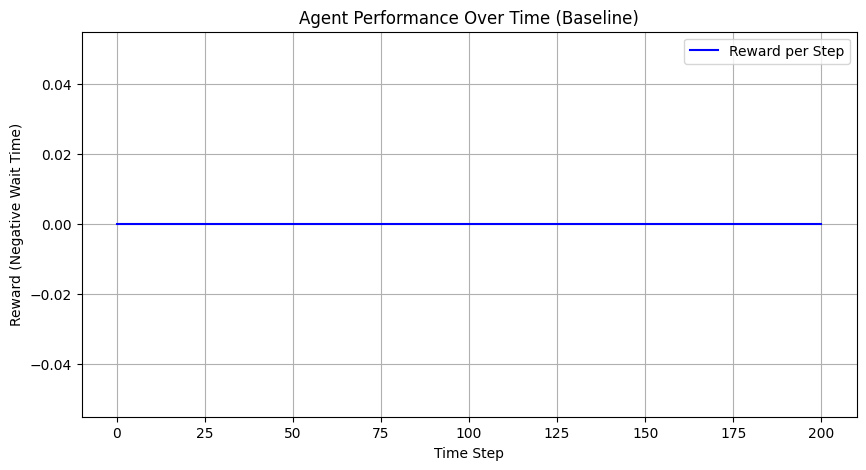

In [ ]:
# 1. Setup
env = TrafficEnv()
agent = FixedTimeAgent(cycle_duration=30)

# 2. Storage for plotting
queues_over_time = []
rewards_over_time = []

# 3. Run one episode
obs, info = env.reset()
done = False
truncated = False
step = 0

while not (done or truncated):
    action = agent.act(obs)
    obs, reward, done, truncated, info = env.step(action)
    
    # Store data for plotting
    # Note: Since env logic isn't finished, rewards are 0.
    # Once car locig pushed, this graph will become real.
    rewards_over_time.append(reward)
    
    # Let's assume obs[1] and obs[2] are the queue buckets (NS and EW)
    # We save them to visualize congestion
    queues_over_time.append((obs[1], obs[2]))
    
    step += 1
    if step > 200: break # testing

print(f"Simulation finished after {step} steps.")

# 4. Plotting
plt.figure(figsize=(10, 5))
plt.plot(rewards_over_time, label="Reward per Step", color='blue')
plt.title("Agent Performance Over Time (Baseline)")
plt.xlabel("Time Step")
plt.ylabel("Reward (Negative Wait Time)")
plt.legend()
plt.grid(True)
plt.show()
